In [1]:
# Persiapan eksperimen Asymmetric Loss

from pathlib import Path
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights


# Konfigurasi yang disamakan dengan baseline BCE
SEED = 42
BATCH_SIZE = 16
NUM_WORKERS = 2
IMAGE_SIZE = 224
ASL_GAMMA_NEG = 4.0
ASL_GAMMA_POS = 1.0
ASL_CLIP = 0.05

LABELS = ["N", "D", "G", "C", "A", "H", "M", "O"]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# Menetapkan seed agar eksperimen dapat diulang
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Lokasi dataset Kaggle
DATASET_DIR = Path(
    "/kaggle/input/datasets/kevinardhana/"
    "odir-5k-patient-level-multi-label-fundus-dataset"
)

IMAGE_DIR = (
    DATASET_DIR
    / "Training Images"
    / "Training Images"
)

TRAIN_CSV = DATASET_DIR / "train.csv"
VALID_CSV = DATASET_DIR / "validation.csv"
TEST_CSV = DATASET_DIR / "test.csv"

ASL_OUTPUT_DIR = Path(
    "/kaggle/working/asl"
)
ASL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Memuat pembagian data
asl_train_df = pd.read_csv(TRAIN_CSV)
asl_valid_df = pd.read_csv(VALID_CSV)
asl_test_df = pd.read_csv(TEST_CSV)


# Memeriksa ukuran dan pemisahan pasien
assert len(asl_train_df) == 2450
assert len(asl_valid_df) == 525
assert len(asl_test_df) == 525

assert set(asl_train_df["patient_id"]).isdisjoint(
    asl_valid_df["patient_id"]
)

assert set(asl_train_df["patient_id"]).isdisjoint(
    asl_test_df["patient_id"]
)

assert set(asl_valid_df["patient_id"]).isdisjoint(
    asl_test_df["patient_id"]
)


# Ringkasan distribusi label hanya dari data training
positive_counts = asl_train_df[LABELS].sum()
negative_counts = len(asl_train_df) - positive_counts

class_distribution_table = pd.DataFrame({
    "label": LABELS,
    "positif_train": positive_counts.values.astype(int),
    "negatif_train": negative_counts.values.astype(int)
})


# Transformasi citra
asl_train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

asl_eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Dataset pasangan mata kiri dan kanan
class ASLFundusPairDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        left_path = self.image_dir / row["left_image"]
        right_path = self.image_dir / row["right_image"]

        left_image = Image.open(left_path).convert("RGB")
        right_image = Image.open(right_path).convert("RGB")

        left_image = self.transform(left_image)
        right_image = self.transform(right_image)

        labels = torch.tensor(
            row[LABELS].values.astype(np.float32),
            dtype=torch.float32
        )

        return {
            "left_image": left_image,
            "right_image": right_image,
            "labels": labels,
            "patient_id": int(row["patient_id"])
        }


asl_train_dataset = ASLFundusPairDataset(
    asl_train_df,
    IMAGE_DIR,
    asl_train_transform
)

asl_valid_dataset = ASLFundusPairDataset(
    asl_valid_df,
    IMAGE_DIR,
    asl_eval_transform
)

asl_test_dataset = ASLFundusPairDataset(
    asl_test_df,
    IMAGE_DIR,
    asl_eval_transform
)


asl_train_loader = DataLoader(
    asl_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda"
)

asl_valid_loader = DataLoader(
    asl_valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda"
)

asl_test_loader = DataLoader(
    asl_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda"
)


# Arsitektur yang sama dengan baseline BCE
class ASLSharedResNet50(nn.Module):
    def __init__(self, num_labels=8, dropout=0.30):
        super().__init__()

        self.backbone = resnet50(
            weights=ResNet50_Weights.IMAGENET1K_V2
        )

        feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(feature_dim * 2, num_labels)
        )

    def forward(self, left_image, right_image):
        left_features = self.backbone(left_image)
        right_features = self.backbone(right_image)

        combined_features = torch.cat(
            [left_features, right_features],
            dim=1
        )

        return self.classifier(combined_features)


asl_model = ASLSharedResNet50(
    num_labels=len(LABELS)
).to(DEVICE)


# Perbedaan utama dari BCE standar
class AsymmetricLoss(nn.Module):
    def __init__(
        self,
        gamma_neg=4.0,
        gamma_pos=1.0,
        clip=0.05,
        eps=1e-8
    ):
        super().__init__()
        if gamma_neg < 0.0 or gamma_pos < 0.0:
            raise ValueError("gamma tidak boleh negatif.")
        if clip < 0.0:
            raise ValueError("clip tidak boleh negatif.")
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, logits, targets):
        positive_probabilities = torch.sigmoid(logits)
        negative_probabilities = 1.0 - positive_probabilities

        if self.clip > 0.0:
            negative_probabilities = (
                negative_probabilities + self.clip
            ).clamp(max=1.0)

        positive_loss = targets * torch.log(
            positive_probabilities.clamp(min=self.eps)
        )
        negative_loss = (1.0 - targets) * torch.log(
            negative_probabilities.clamp(min=self.eps)
        )
        loss = positive_loss + negative_loss

        with torch.no_grad():
            positive_focus = 1.0 - positive_probabilities
            negative_focus = 1.0 - negative_probabilities
            asymmetric_focus = (
                positive_focus * targets
                + negative_focus * (1.0 - targets)
            )
            asymmetric_gamma = (
                self.gamma_pos * targets
                + self.gamma_neg * (1.0 - targets)
            )
            asymmetric_weight = asymmetric_focus.pow(
                asymmetric_gamma
            )

        return -(asymmetric_weight * loss).mean()


asl_criterion = AsymmetricLoss(
    gamma_neg=ASL_GAMMA_NEG,
    gamma_pos=ASL_GAMMA_POS,
    clip=ASL_CLIP
)


# Pemeriksaan satu batch
asl_batch = next(iter(asl_train_loader))

left_batch = asl_batch["left_image"].to(DEVICE)
right_batch = asl_batch["right_image"].to(DEVICE)
label_batch = asl_batch["labels"].to(DEVICE)

with torch.no_grad():
    asl_logits = asl_model(
        left_batch,
        right_batch
    )


print("Persiapan Asymmetric Loss berhasil.")
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nJumlah data:")
print("Train      :", len(asl_train_dataset))
print("Validation :", len(asl_valid_dataset))
print("Test       :", len(asl_test_dataset))

print("\nBentuk input:")
print("Citra kiri :", left_batch.shape)
print("Citra kanan:", right_batch.shape)
print("Label      :", label_batch.shape)
print("Logits     :", asl_logits.shape)

print("\nParameter Asymmetric Loss:")
print("Gamma negatif:", ASL_GAMMA_NEG)
print("Gamma positif:", ASL_GAMMA_POS)
print("Clip:", ASL_CLIP)

print("\nDistribusi label data training:")
display(class_distribution_table)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 162MB/s]


Persiapan Asymmetric Loss berhasil.
Device: cuda
GPU: Tesla T4

Jumlah data:
Train      : 2450
Validation : 525
Test       : 525

Bentuk input:
Citra kiri : torch.Size([16, 3, 224, 224])
Citra kanan: torch.Size([16, 3, 224, 224])
Label      : torch.Size([16, 8])
Logits     : torch.Size([16, 8])

Parameter Asymmetric Loss:
Gamma negatif: 4.0
Gamma positif: 1.0
Clip: 0.05

Distribusi label data training:


,label,positif_train,negatif_train
0,N,796,1654
1,D,790,1660
2,G,151,2299
3,C,148,2302
4,A,115,2335
5,H,72,2378
6,M,122,2328
7,O,685,1765


In [2]:
# Training Asymmetric Loss

import json
from sklearn.metrics import f1_score
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau


LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 7


asl_optimizer = AdamW(
    asl_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

asl_scheduler = ReduceLROnPlateau(
    asl_optimizer,
    mode="max",
    factor=0.5,
    patience=2
)


def train_asl_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        left_images = batch["left_image"].to(
            device,
            non_blocking=True
        )
        right_images = batch["right_image"].to(
            device,
            non_blocking=True
        )
        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        logits = model(left_images, right_images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples


@torch.no_grad()
def evaluate_weighted(
    model,
    loader,
    criterion,
    device,
    threshold=0.5
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_probabilities = []

    for batch in loader:
        left_images = batch["left_image"].to(
            device,
            non_blocking=True
        )
        right_images = batch["right_image"].to(
            device,
            non_blocking=True
        )
        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        logits = model(left_images, right_images)
        loss = criterion(logits, labels)

        probabilities = torch.sigmoid(logits)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_labels.append(labels.cpu().numpy())
        all_probabilities.append(
            probabilities.cpu().numpy()
        )

    true_labels = np.concatenate(
        all_labels,
        axis=0
    )

    probabilities = np.concatenate(
        all_probabilities,
        axis=0
    )

    predictions = (
        probabilities >= threshold
    ).astype(np.int32)

    macro_f1 = f1_score(
        true_labels,
        predictions,
        average="macro",
        zero_division=0
    )

    micro_f1 = f1_score(
        true_labels,
        predictions,
        average="micro",
        zero_division=0
    )

    return {
        "loss": total_loss / total_samples,
        "macro_f1": float(macro_f1),
        "micro_f1": float(micro_f1)
    }


asl_history = []
asl_best_macro_f1 = -1.0
asl_best_epoch = 0
asl_patience_counter = 0

asl_checkpoint_path = (
    ASL_OUTPUT_DIR
    / "best_asl_resnet50.pt"
)

asl_history_path = (
    ASL_OUTPUT_DIR
    / "training_history.json"
)


for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_asl_one_epoch(
        model=asl_model,
        loader=asl_train_loader,
        criterion=asl_criterion,
        optimizer=asl_optimizer,
        device=DEVICE
    )

    validation_result = evaluate_weighted(
        model=asl_model,
        loader=asl_valid_loader,
        criterion=asl_criterion,
        device=DEVICE,
        threshold=0.5
    )

    validation_loss = validation_result["loss"]
    validation_macro_f1 = validation_result["macro_f1"]
    validation_micro_f1 = validation_result["micro_f1"]

    asl_scheduler.step(
        validation_macro_f1
    )

    current_lr = asl_optimizer.param_groups[0]["lr"]

    epoch_result = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        "validation_loss": float(validation_loss),
        "validation_macro_f1": validation_macro_f1,
        "validation_micro_f1": validation_micro_f1,
        "learning_rate": float(current_lr)
    }

    asl_history.append(epoch_result)

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"train loss: {train_loss:.4f} | "
        f"val loss: {validation_loss:.4f} | "
        f"val Macro-F1: {validation_macro_f1:.4f} | "
        f"val Micro-F1: {validation_micro_f1:.4f} | "
        f"lr: {current_lr:.6f}"
    )

    if validation_macro_f1 > asl_best_macro_f1:
        asl_best_macro_f1 = validation_macro_f1
        asl_best_epoch = epoch
        asl_patience_counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    asl_model.state_dict(),
                "optimizer_state_dict":
                    asl_optimizer.state_dict(),
                "best_macro_f1":
                    asl_best_macro_f1,
                "labels": LABELS,
                "asl_gamma_neg": ASL_GAMMA_NEG,
                "asl_gamma_pos": ASL_GAMMA_POS,
                "asl_clip": ASL_CLIP,
                "image_size": IMAGE_SIZE,
                "dropout": 0.30,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "seed": SEED
            },
            asl_checkpoint_path
        )

        print("  Checkpoint terbaik disimpan.")

    else:
        asl_patience_counter += 1

    with open(asl_history_path, "w") as file:
        json.dump(
            asl_history,
            file,
            indent=2
        )

    if (
        asl_patience_counter
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            f"Early stopping pada epoch {epoch}. "
            f"Checkpoint terbaik: epoch "
            f"{asl_best_epoch}."
        )
        break


print("\nTraining Asymmetric Loss selesai.")
print("Best epoch:", asl_best_epoch)
print(
    "Best validation Macro-F1:",
    f"{asl_best_macro_f1:.4f}"
)
print("Checkpoint:", asl_checkpoint_path)
print("History:", asl_history_path)

Epoch 01/30 | train loss: 0.0628 | val loss: 0.0575 | val Macro-F1: 0.3770 | val Micro-F1: 0.4521 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 02/30 | train loss: 0.0557 | val loss: 0.0578 | val Macro-F1: 0.4241 | val Micro-F1: 0.4843 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 03/30 | train loss: 0.0525 | val loss: 0.0551 | val Macro-F1: 0.4548 | val Micro-F1: 0.4849 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 04/30 | train loss: 0.0484 | val loss: 0.0522 | val Macro-F1: 0.4733 | val Micro-F1: 0.4998 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 05/30 | train loss: 0.0461 | val loss: 0.0532 | val Macro-F1: 0.4940 | val Micro-F1: 0.5113 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 06/30 | train loss: 0.0434 | val loss: 0.0533 | val Macro-F1: 0.5239 | val Micro-F1: 0.5287 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 07/30 | train loss: 0.0401 | val loss: 0.0556 | val Macro-F1: 0.4930 | val Micro-F1: 0.5272 | lr: 0.000100
Epoch 08/30 | train los

In [3]:
# Menentukan threshold setiap label dari validation set

from sklearn.metrics import f1_score


checkpoint = torch.load(
    asl_checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

asl_model.load_state_dict(
    checkpoint["model_state_dict"]
)

asl_model.eval()


@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()

    patient_ids = []
    all_labels = []
    all_probabilities = []

    for batch in loader:
        left_images = batch["left_image"].to(
            device,
            non_blocking=True
        )
        right_images = batch["right_image"].to(
            device,
            non_blocking=True
        )

        logits = model(left_images, right_images)
        probabilities = torch.sigmoid(logits)

        patient_ids.extend(
            batch["patient_id"].cpu().numpy().tolist()
        )
        all_labels.append(
            batch["labels"].cpu().numpy()
        )
        all_probabilities.append(
            probabilities.cpu().numpy()
        )

    return (
        np.asarray(patient_ids),
        np.concatenate(all_labels, axis=0),
        np.concatenate(all_probabilities, axis=0)
    )


(
    validation_patient_ids,
    validation_labels,
    validation_probabilities
) = collect_predictions(
    asl_model,
    asl_valid_loader,
    DEVICE
)


threshold_candidates = np.arange(
    0.05,
    0.96,
    0.01
)

best_thresholds = []
best_validation_f1 = []


for label_index, label_name in enumerate(LABELS):
    label_scores = []

    for threshold in threshold_candidates:
        label_predictions = (
            validation_probabilities[:, label_index]
            >= threshold
        ).astype(np.int32)

        score = f1_score(
            validation_labels[:, label_index],
            label_predictions,
            zero_division=0
        )

        label_scores.append(score)

    best_index = int(np.argmax(label_scores))

    best_thresholds.append(
        float(threshold_candidates[best_index])
    )
    best_validation_f1.append(
        float(label_scores[best_index])
    )


best_thresholds = np.asarray(
    best_thresholds,
    dtype=np.float32
)


default_predictions = (
    validation_probabilities >= 0.5
).astype(np.int32)

tuned_predictions = (
    validation_probabilities >= best_thresholds
).astype(np.int32)


default_validation_macro_f1 = f1_score(
    validation_labels,
    default_predictions,
    average="macro",
    zero_division=0
)

tuned_validation_macro_f1 = f1_score(
    validation_labels,
    tuned_predictions,
    average="macro",
    zero_division=0
)


threshold_table = pd.DataFrame({
    "label": LABELS,
    "threshold_terbaik": best_thresholds,
    "F1_validation": best_validation_f1,
    "jumlah_positif_validation":
        validation_labels.sum(axis=0).astype(int)
})


threshold_path = (
    ASL_OUTPUT_DIR
    / "best_thresholds.json"
)

with open(threshold_path, "w") as file:
    json.dump(
        {
            "checkpoint_epoch": int(checkpoint["epoch"]),
            "default_validation_macro_f1":
                float(default_validation_macro_f1),
            "tuned_validation_macro_f1":
                float(tuned_validation_macro_f1),
            "thresholds": {
                label: float(threshold)
                for label, threshold in zip(
                    LABELS,
                    best_thresholds
                )
            },
            "validation_f1_per_label": {
                label: float(score)
                for label, score in zip(
                    LABELS,
                    best_validation_f1
                )
            }
        },
        file,
        indent=2
    )


print("Checkpoint terbaik: epoch", checkpoint["epoch"])
print(
    "Validation Macro-F1 threshold 0,50:",
    f"{default_validation_macro_f1:.4f}"
)
print(
    "Validation Macro-F1 threshold per label:",
    f"{tuned_validation_macro_f1:.4f}"
)

display(threshold_table)
print("Threshold disimpan di:", threshold_path)

Checkpoint terbaik: epoch 18
Validation Macro-F1 threshold 0,50: 0.5730
Validation Macro-F1 threshold per label: 0.6156


,label,threshold_terbaik,F1_validation,jumlah_positif_validation
0,N,0.38,0.607966,171
1,D,0.68,0.648968,169
2,G,0.50,0.558824,32
3,C,0.81,0.862069,32
4,A,0.61,0.625000,25
5,H,0.53,0.296296,16
6,M,0.62,0.840000,26
7,O,0.58,0.485549,147


Threshold disimpan di: /kaggle/working/asl/best_thresholds.json


In [4]:
# Evaluasi final Asymmetric Loss pada test set

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    hamming_loss,
    multilabel_confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score
)


(
    test_patient_ids,
    test_labels,
    test_probabilities
) = collect_predictions(
    asl_model,
    asl_test_loader,
    DEVICE
)


test_predictions = (
    test_probabilities >= best_thresholds
).astype(np.int32)


test_macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

test_micro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="micro",
    zero_division=0
)

test_macro_auroc = roc_auc_score(
    test_labels,
    test_probabilities,
    average="macro"
)

test_hamming_loss = hamming_loss(
    test_labels,
    test_predictions
)

test_subset_accuracy = accuracy_score(
    test_labels,
    test_predictions
)


precision, recall, label_f1, support = (
    precision_recall_fscore_support(
        test_labels,
        test_predictions,
        average=None,
        zero_division=0
    )
)

label_auroc = [
    roc_auc_score(
        test_labels[:, index],
        test_probabilities[:, index]
    )
    for index in range(len(LABELS))
]

confusion_matrices = multilabel_confusion_matrix(
    test_labels,
    test_predictions
)


per_label_results = []

for index, label_name in enumerate(LABELS):
    tn, fp, fn, tp = (
        confusion_matrices[index].ravel()
    )

    per_label_results.append({
        "label": label_name,
        "precision": float(precision[index]),
        "recall": float(recall[index]),
        "f1_score": float(label_f1[index]),
        "auroc": float(label_auroc[index]),
        "support": int(support[index]),
        "threshold": float(best_thresholds[index]),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    })


per_label_table = pd.DataFrame(
    per_label_results
)


test_summary = {
    "loss_function": "Asymmetric Loss",
    "backbone": "ResNet50",
    "asl_gamma_neg": ASL_GAMMA_NEG,
    "asl_gamma_pos": ASL_GAMMA_POS,
    "asl_clip": ASL_CLIP,
    "checkpoint_epoch": int(checkpoint["epoch"]),
    "validation_macro_f1":
        float(tuned_validation_macro_f1),
    "test_macro_f1": float(test_macro_f1),
    "test_micro_f1": float(test_micro_f1),
    "test_macro_auroc": float(test_macro_auroc),
    "test_hamming_loss": float(test_hamming_loss),
    "test_subset_accuracy":
        float(test_subset_accuracy)
}


print("Hasil final test set Asymmetric Loss")
print("Checkpoint epoch:", checkpoint["epoch"])
print("Macro-F1       :", f"{test_macro_f1:.4f}")
print("Micro-F1       :", f"{test_micro_f1:.4f}")
print("Macro-AUROC    :", f"{test_macro_auroc:.4f}")
print("Hamming loss   :", f"{test_hamming_loss:.4f}")
print(
    "Subset accuracy:",
    f"{test_subset_accuracy:.4f}"
)

print("\nHasil setiap label:")
display(per_label_table)

Hasil final test set Asymmetric Loss
Checkpoint epoch: 18
Macro-F1       : 0.6034
Micro-F1       : 0.5867
Macro-AUROC    : 0.8511
Hamming loss   : 0.1395
Subset accuracy: 0.3429

Hasil setiap label:


,label,precision,recall,f1_score,auroc,support,threshold,TN,FP,FN,TP
0,N,0.471761,0.820809,0.599156,0.761265,173,0.38,193,159,31,142
1,D,0.540984,0.585799,0.562500,0.753191,169,0.68,272,84,70,99
2,G,0.485714,0.531250,0.507463,0.856301,32,0.50,475,18,15,17
3,C,0.884615,0.718750,0.793103,0.949544,32,0.81,490,3,9,23
4,A,0.733333,0.458333,0.564103,0.916001,24,0.61,497,4,13,11
5,H,0.416667,0.333333,0.370370,0.821569,15,0.53,503,7,10,5
6,M,0.954545,0.807692,0.875000,0.995992,26,0.62,498,1,5,21
7,O,0.475728,0.666667,0.555241,0.754886,147,0.58,270,108,49,98


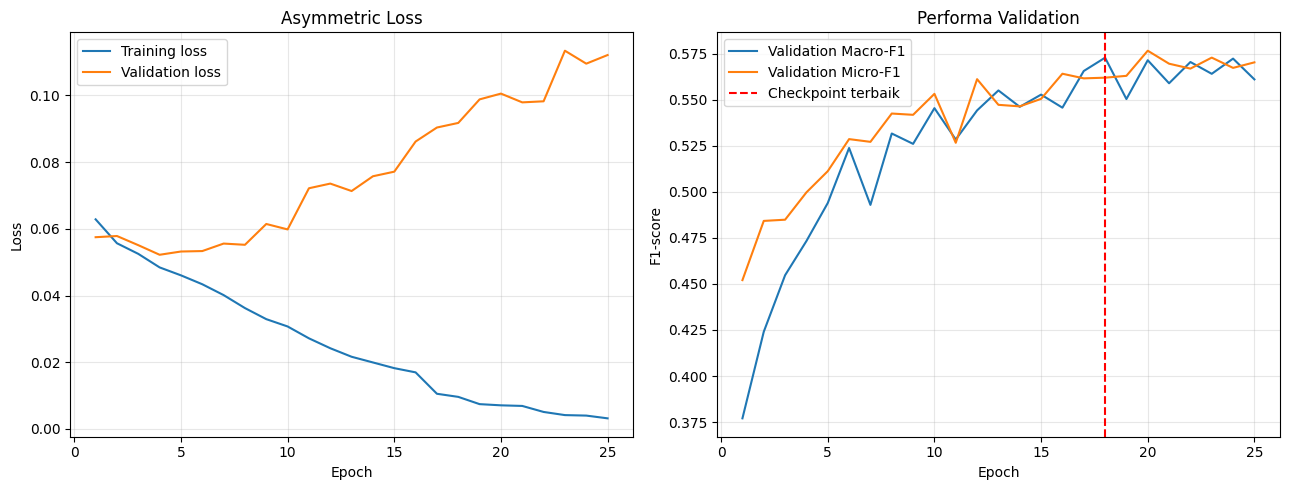

Artefak Asymmetric Loss berhasil disimpan:

- asl_parameters.json: 0.06 KB
- best_asl_resnet50.pt: 276325.02 KB
- best_thresholds.json: 0.60 KB
- class_distribution.csv: 0.12 KB
- test_metrics_per_label.csv: 0.89 KB
- test_predictions.csv: 63.73 KB
- test_summary.json: 0.41 KB
- training_curves.png: 168.35 KB
- training_history.json: 5.64 KB


In [5]:
# Menyimpan seluruh artefak Asymmetric Loss

import matplotlib.pyplot as plt


summary_path = (
    ASL_OUTPUT_DIR
    / "test_summary.json"
)

per_label_path = (
    ASL_OUTPUT_DIR
    / "test_metrics_per_label.csv"
)

prediction_path = (
    ASL_OUTPUT_DIR
    / "test_predictions.csv"
)

distribution_path = (
    ASL_OUTPUT_DIR
    / "class_distribution.csv"
)

parameter_path = (
    ASL_OUTPUT_DIR
    / "asl_parameters.json"
)

curve_path = (
    ASL_OUTPUT_DIR
    / "training_curves.png"
)


with open(summary_path, "w") as file:
    json.dump(
        test_summary,
        file,
        indent=2
    )


per_label_table.to_csv(
    per_label_path,
    index=False
)

class_distribution_table.to_csv(
    distribution_path,
    index=False
)

with open(parameter_path, "w") as file:
    json.dump(
        {
            "gamma_neg": ASL_GAMMA_NEG,
            "gamma_pos": ASL_GAMMA_POS,
            "clip": ASL_CLIP
        },
        file,
        indent=2
    )


prediction_data = {
    "patient_id": test_patient_ids
}

for index, label_name in enumerate(LABELS):
    prediction_data[f"true_{label_name}"] = (
        test_labels[:, index].astype(int)
    )
    prediction_data[f"prob_{label_name}"] = (
        test_probabilities[:, index]
    )
    prediction_data[f"pred_{label_name}"] = (
        test_predictions[:, index].astype(int)
    )


prediction_table = pd.DataFrame(
    prediction_data
)

prediction_table.to_csv(
    prediction_path,
    index=False
)


history_table = pd.DataFrame(
    asl_history
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)


axes[0].plot(
    history_table["epoch"],
    history_table["train_loss"],
    label="Training loss"
)

axes[0].plot(
    history_table["epoch"],
    history_table["validation_loss"],
    label="Validation loss"
)

axes[0].set_title("Asymmetric Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].plot(
    history_table["epoch"],
    history_table["validation_macro_f1"],
    label="Validation Macro-F1"
)

axes[1].plot(
    history_table["epoch"],
    history_table["validation_micro_f1"],
    label="Validation Micro-F1"
)

axes[1].axvline(
    checkpoint["epoch"],
    color="red",
    linestyle="--",
    label="Checkpoint terbaik"
)

axes[1].set_title("Performa Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1-score")
axes[1].legend()
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.savefig(
    curve_path,
    dpi=200,
    bbox_inches="tight"
)
plt.show()


print("Artefak Asymmetric Loss berhasil disimpan:\n")

for path in sorted(ASL_OUTPUT_DIR.iterdir()):
    print(
        f"- {path.name}: "
        f"{path.stat().st_size / 1024:.2f} KB"
    )